# A/B Test: which landing page version should we keep?

An ecommerce company tested two versions of its landing page over 28 days. The decision on the table is which one gets rolled out to 100% of traffic.

That question is not answered by checking which version sold more in total: the groups could differ in size, and any gap could come from chance. It requires separating signal from noise, and that is what this analysis does.

I work with `landing_experiment.csv`, one row per user, recording the version they saw, their region, device, acquisition channel, user type, whether they converted and how much they spent.

**The four questions I answer, and why in this order:**

1. Which version produces higher spend per converted customer?
2. Which version converts a higher share of visitors?
3. Does conversion depend on the channel the user came from?
4. Does conversion depend on whether the user is new or returning?

The first two break revenue into its two components — how many buy, and how much each one spends — because a version can win on one and lose on the other. The last two check whether the effect is uniform or whether the rollout needs to be segmented.

Each question uses the test that matches the variable type, not the one that returns the most convenient result. I close with a business recommendation and its limitations.

## 1. Dataset validation

Before comparing anything I check that the data can support the analysis: no nulls, no duplicates, correctly spelled categories and — the one that matters most in an A/B test — two groups comparable in size.

In [25]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [26]:
# The dataset is not versioned in this repository; place it under data/ to re-run
df = pd.read_csv('data/landing_experiment.csv')

### Overall structure and quality

In [27]:
# First rows, to see the shape of the data
df.head()


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [28]:
# Types, nulls and duplicates in a single pass
df.info()
print()
print('duplicate_rows',df.duplicated().sum())
print()
print('null_values',df.isna().sum())
print()
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB

duplicate_rows 0

null_values user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro   

The dataset holds 40,000 records across 9 columns.

**Data quality:**
- No null values in any column.
- No duplicate records.
- Categorical columns carry no stray whitespace and no categories that mean the
same thing written two different ways.

**The only fix needed:**
- `date` comes in as `object`. I convert it to `datetime` so I can bound the
experiment window and confirm both versions ran in parallel rather than one after the other.

### Data dictionary

- `user_id` — unique user identifier
- `date` — day the user was exposed to the page
- `landing` — version shown: A (control) or B (variant)
- `region` — geographic region
- `dispositivo` — Mobile or Desktop
- `traffic_source` — acquisition channel
- `user_type` — Nuevo (new) or Recurrente (returning)
- `converted` — 1 if the user converted, 0 otherwise
- `gasto` — amount spent, **0 when there was no conversion**

That last note is the trap in this dataset: comparing `gasto` without filtering lets the zeros from non-buyers drag both averages down and hide the real difference between versions.

> Column names stay in Spanish because they come from the source file.

### Key experiment variables

I go through the variables that feed the analysis one by one.

**`user_id`**

Check that every row is a distinct user

In [29]:
df['user_id'].nunique()

40000

**`date`**

Check the experiment window

In [30]:

# Summary statistics
df["date"].describe()


count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [31]:
# Experiment time window
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())

Min date: 2026-01-01
Max date: 2026-01-28


**`gasto` (numeric)**

In [32]:
# Summary statistics
print(df['gasto'].describe())

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [33]:
# Same summary, now only for converted users: the mean jumps from 9.33 to 65.37
df[df['converted']==1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

**Categorical variables**

Check the expected experiment categories (A and B).

In [34]:
# Distribution of each categorical, to catch misspelled values
print("\nCategory counts:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Category counts:

--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


In [53]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
print(df['date'].dtype)
print('Experiment window:', df['date'].min(), 'to', df['date'].max())

datetime64[ns]
Experiment window: 2026-01-01 00:00:00 a 2026-01-28 00:00:00


The categorical columns carry the expected values: no misspelled categories, no implicit duplicates.

The figure that matters most here is the group balance: 19,982 users saw version A and 20,018 saw version B — a gap of 36 users out of 40,000. The groups are comparable, so any difference I find later is not explained by an uneven traffic split.

## 2. Which version produces higher spend per customer?

I compare average spend for users **who already converted** in each version. I filter on `converted == 1` before comparing: including non-buyers would push thousands of zeros into both groups and the average would measure something else entirely.

In [35]:
# Spend of users who DID convert, split by version.
# The converted==1 filter is what keeps the zeros from skewing the mean.
spend_A = df[(df['converted'] == 1) & (df['landing'] == 'A')]['gasto']
spend_B = df[(df['converted'] == 1) & (df['landing'] == 'B')]['gasto']

# Group sizes: both exceed 2,000 records, enough for the t-test
len(spend_A), len(spend_B)

(2512, 3194)

### Levene's test (homogeneity of variances)

Before the t-test I need to know whether both groups have similar spread, since that determines which variant of the t-test applies.

- **H₀:** spend variance is equal between A and B.
- **H₁:** spend variance differs between A and B.

This test answers no business question; it decides whether the t-test assumes equal variances (`equal_var=True`) or not (`equal_var=False`).

### t-test for independent samples

- **H₀:** average spend among converted users in A equals that of B.
- **H₁:** average spend among converted users in A differs from that of B.

Significance level: α = 0.05.

In [36]:
# Levene decides which variant of the t-test to use
l_stat, p_levene = levene(spend_A, spend_B)


print(f"Statistic: {l_stat}")
print(f"p-value: {p_levene}")

Statistic: 29.17646453202917
p-value: 6.875301988016449e-08


In [37]:
t_stat, p_value = ttest_ind(spend_A, spend_B, equal_var= False)

print(f"t_stat: {t_stat}")
print(f"p_value: {p_value}")

t_stat: -9.48101092267275
p_value: 3.627602231521493e-21


In [38]:
print(f"Average spend A: {spend_A.mean():.2f}")
print(f"Average spend B: {spend_B.mean():.2f}")
print(f"Difference: {spend_B.mean() - spend_A.mean():.2f}")

Average spend A: 61.09
Average spend B: 68.75
Difference: 7.66


### Result

**Decision:**

I reject the null hypothesis. Welch's t-test returned p = 3.63e-21, below the α = 0.05 threshold, so there is sufficient statistical evidence that average spend among converted users differs between page A and page B.

**Business interpretation:**

Among users who converted, page B produced an average spend of 68.75 against 61.09 for page A: 7.66 more per converted user, a 12.5% increase. The gap is not explained by chance, which indicates page B generates greater economic value per customer.

**Methodological note:** Levene's test returned p = 6.88e-08 — heterogeneous variances — so I used Welch's t-test (`equal_var=False`) rather than the classic t-test. Skipping that check would have inflated the confidence of the result.

**Limitations:** the result covers only converted users within a 28-day window, measures difference rather than causation, and does not weigh the cost of implementing page B against the observed lift.

---

## 3. Which version converts more visitors?

Spend per customer is only half of revenue. Here I compare the other half: what share of visitors reaches a purchase in each version. Since the variable is binary — converted or not — the comparison is between two rates rather than two averages, so the test changes.

### Two-proportion z-test

**Hypotheses:**
- **H₀:** the conversion rate of page A equals the conversion rate of page B.
- **H₁:** the conversion rate of page A differs from that of page B.

I use the two-proportion z-test because `converted` is binary (0 / 1) and the comparison is between two rates, not two means.

Significance level: α = 0.05.

In [39]:

# Number of users convertidos por página
converted_users_A= df[(df['converted']==1)&(df['landing']=='A')]['user_id'].count()
converted_users_B= df[(df['converted']==1)&(df['landing']=='B')]['user_id'].count()

# Total users per page
total_users_A= df[df['landing']== 'A']['converted'].count() 
total_users_B= df[df['landing']== 'B']['converted'].count() 
print("Converted users per page (A, B):\n", converted_users_A, converted_users_B)
print("\nTotal users per page (A, B):\n", total_users_A, total_users_B)



Converted users per page (A, B):
 2512 3194

Total users per page (A, B):
 19982 20018


In [40]:
print('conversion_rate_A', converted_users_A/total_users_A)
print('conversion_rate_B', converted_users_B/total_users_B)
print('difference', (converted_users_A/total_users_A)- (converted_users_B/total_users_B))

conversion_rate_A 0.12571314182764487
conversion_rate_B 0.15955639924068338
difference -0.03384325741303851


In [41]:
# El z-test recibe conteos de éxitos y de observations, no source_rates
successes = [converted_users_A, converted_users_B]
observations = [total_users_A, total_users_B]
z_stat, p_value = proportions_ztest(successes, observations)

print(f"Statistic: {z_stat}")
print(f"p-value: {p_value}")


Statistic: -9.677362674655983
p-value: 3.7629765627523803e-22


### Result

**Decision:**

I reject the null hypothesis. The two-proportion z-test returned p = 3.76e-22, below α = 0.05, so there is sufficient statistical evidence that conversion rate differs between page A and page B.

**Business interpretation:**

Page B converted 15.96% of its visitors (3,194 of 20,018) against 12.57% for page A (2,512 of 19,982). The gap is 3.38 percentage points, a 26.9% relative increase in conversion capacity.

Together with the previous result, B beats A on both components of revenue: it converts more users and each one spends more. The two effects multiply rather than add, and that is what supports the final recommendation.

**Limitations:** the result holds for the experiment window and does not guarantee the difference persists over time. It also does not rule out a novelty effect: a new page can perform better simply because it is different.

## 4. Does conversion depend on the acquisition channel?

I already know which version wins. Now I check whether the channel a user arrives through changes their probability of converting. Both are categorical variables, so the question is not "which average is higher?" but "do they behave independently?".

### Chi-square test of independence

**Hypotheses:**
- **H₀:** traffic source and conversion are independent; conversion rate does
not depend on the channel the user arrived through.
- **H₁:** traffic source and conversion are not independent; there is an
association between acquisition channel and probability of conversion.

Significance level: α = 0.05.

In [42]:
# The test runs on raw counts, not on proportions
source_table =pd.crosstab(df['traffic_source'], df['converted'])
source_table

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [43]:

chi2, p, dof, expected = chi2_contingency(source_table)
print('statistic', chi2)
print('p-value', p)
print('Expected frequencies:')
print(pd.DataFrame(expected, index=source_table.index, columns=source_table.columns).round(1))
print()
source_rates = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')
print((source_rates * 100).round(2))


statistic 8.662108841397938
p-value 0.0341375947833914
Expected frequencies:
converted             0       1
traffic_source                 
Ads             10232.5  1702.5
Email            5249.6   873.4
Organic         15421.2  2565.8
Referral         3390.8   564.2

converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


### Result

**Decision:**

I reject the null hypothesis. The chi-square test returned p = 0.0341, below α = 0.05, so there is an association between traffic source and conversion. All expected frequencies exceed 5, satisfying the test's assumption.

**Business interpretation:**

Email (14.99%) and Ads (14.74%) convert above Referral (13.88%) and Organic (13.79%). The spread between the best and worst channel is 1.20 percentage points — less than half the effect observed between page versions (3.38 p.p.). Organic has the lowest rate but carries the highest volume, so it still contributes the largest absolute number of conversions.

**Limitations:** with n = 40,000, small differences turn significant; the effect is statistically detectable but of low practical relevance. The test indicates association, not causation, and does not identify what drives it.

## 5. Does conversion depend on user type?

The last check before recommending: if new and returning users convert at different rates, the rollout would have to be segmented. If they convert alike, the winning version can ship uniformly.

A returning user may have visited before without buying, so "user type" describes visit history, not purchase history.

### Chi-square test of independence

**Hypotheses:**
- **H₀:** user type and conversion are independent; conversion rate does not
depend on whether the user is new or returning.
- **H₁:** user type and conversion are not independent; there is an association
between user type and probability of conversion.

Significance level: α = 0.05.

I keep chi-square for consistency with the previous section, since both questions evaluate the association between a categorical variable and conversion. On a 2×2 table, the two-proportion z-test would have reached an equivalent conclusion.

In [44]:
user_type_table =pd.crosstab(df['user_type'], df['converted'])
user_type_table



converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [45]:

chi2, p, dof, expected = chi2_contingency(user_type_table)
print('statistic', chi2)
print('p-value', p)
print('Expected frequencies:')
print(pd.DataFrame(expected, index=user_type_table.index, columns=user_type_table.columns).round(1))
print()




statistic 0.5134849494478645
p-value 0.4736341272301974
Expected frequencies:
converted         0       1
user_type                  
Nuevo       22319.4  3713.6
Recurrente  11974.6  1992.4



In [46]:
# Row-normalized table: the pattern is read here, not from the p-value
user_type_rates = pd.crosstab(df['user_type'], df['converted'], normalize='index')
print((user_type_rates * 100).round(2))


converted       0      1
user_type               
Nuevo       85.64  14.36
Recurrente  85.91  14.09


### Result

**Decision:**

I do not reject the null hypothesis. The chi-square test returned p = 0.4736, well above α = 0.05, so there is not enough statistical evidence that user type and conversion are associated. All expected frequencies exceed 5, satisfying the test's assumption.

**Business interpretation:**

New users convert at 14.36% and returning users at 14.09%: a 0.27 percentage point gap, indistinguishable from noise. Observed frequencies land almost exactly on the counts expected under independence (3,738 against 3,713 conversions among new users).

This has a favourable operational implication: the redesign performs consistently for both profiles, so there is no need to segment the rollout or maintain differentiated versions by user type. The winning version can ship uniformly.

**Limitations:** failing to reject the null does not prove the absence of a relationship, only that this experiment did not detect one large enough. The interaction between user type and page version was not evaluated here, and it could reveal effects the aggregate analysis misses.

## 6. Reading the data visually: volume against rate

The tests say whether a difference exists, but not where it comes from or how large it is. For that I plot each categorical variable two ways: in absolute counts and in conversion rate.

The distinction matters because the two tell opposite stories. A high-traffic channel dominates the count chart even when it converts poorly, and a small channel with a strong rate disappears. Looking at only one of the two views leads to bad budget decisions.

### Acquisition channel

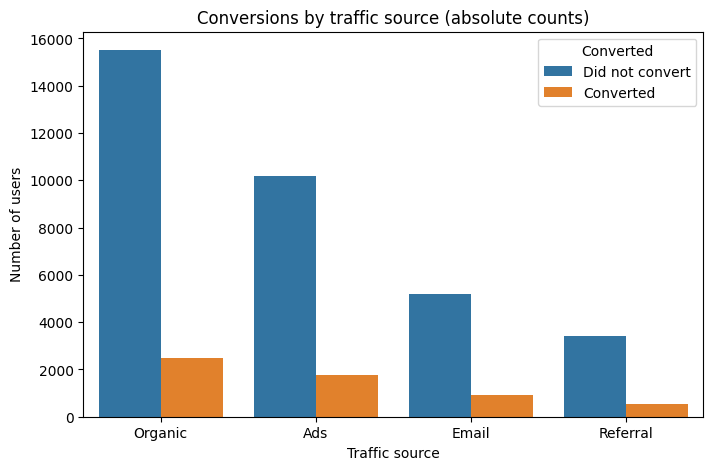

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='traffic_source', hue='converted',
              order=['Organic', 'Ads', 'Email', 'Referral'])
plt.title('Conversions by traffic source (absolute counts)')
plt.xlabel('Traffic source')
plt.ylabel('Number of users')
plt.legend(title='Converted', labels=['Did not convert', 'Converted'])
plt.show()

The chart shows Organic carrying the largest share of users, followed by Ads, Email and Referral. That size difference carries over to absolute conversions: Organic generates the most conversions in the experiment despite having the lowest rate. The absolute view is the relevant one for sizing each channel's contribution to total revenue, but it says nothing about efficiency.

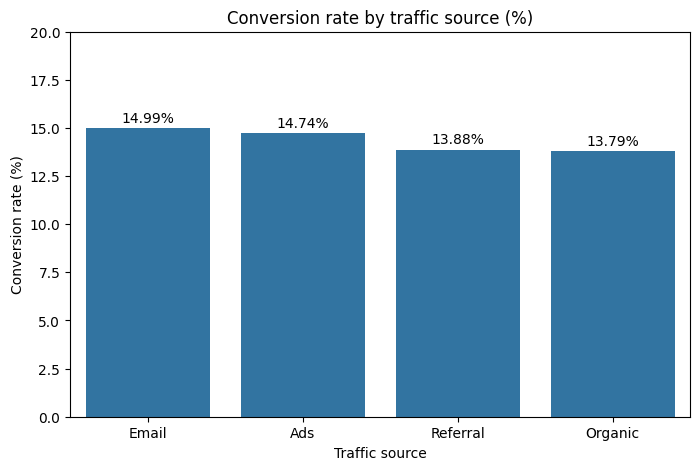

In [48]:

source_rates_pct = (source_rates[1] * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=source_rates_pct.index, y=source_rates_pct.values)
plt.title('Conversion rate by traffic source (%)')
plt.xlabel('Traffic source')
plt.ylabel('Conversion rate (%)')
plt.ylim(0, 20)

for i, v in enumerate(source_rates_pct.values):
    plt.text(i, v + 0.3, f'{v}%', ha='center')

plt.show()


Comparing rates instead of volumes flips the ranking: Email (14.99%) and Ads (14.74%) beat Referral (13.88%) and Organic (13.79%), even though Organic had the most users. I fixed the axis from 0 to 20% so a 1.20 percentage point spread between best and worst channel is not visually exaggerated — consistent with the chi-square result.

Taken together, both charts show that paid and direct channels convert better in proportion, while Organic sustains the largest absolute contribution through sheer traffic volume.

### User type

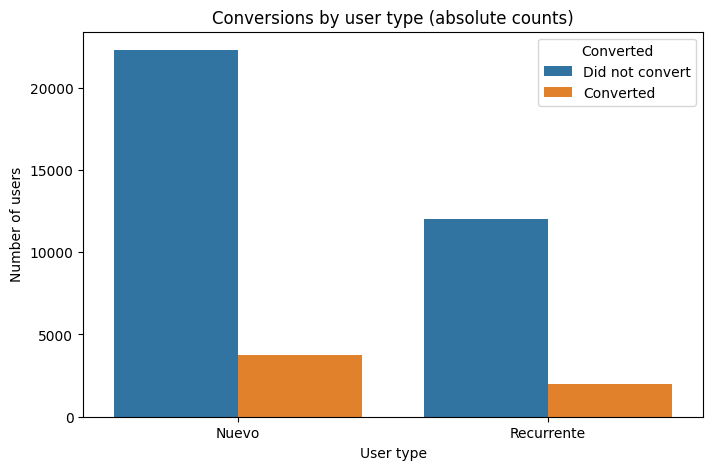

In [49]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='user_type', hue='converted',
              order=['Nuevo', 'Recurrente'])
plt.title('Conversions by user type (absolute counts)')
plt.xlabel('User type')
plt.ylabel('Number of users')
plt.legend(title='Converted', labels=['Did not convert', 'Converted'])
plt.show()

The chart shows new users (26,033) outnumbering returning users (13,967) by roughly 1.9 to 1. That size difference carries into absolute conversions, which are considerably higher among new users.

The chi-square test (p = 0.4736) confirms both profiles convert at equivalent proportions: 14.36% for new users and 14.09% for returning ones, a gap of just 0.27 percentage points. The larger conversion count among new users is explained by group size, not by higher efficiency.

This means the page design performs consistently across both profiles, so there is no need to segment the rollout or build differentiated versions by user type.

**Limitations:** not finding a difference does not mean none exists; it means that if one exists, it is small enough that this experiment cannot tell it apart from noise. The analysis also evaluates user type across the whole experiment without splitting by page version, so an interaction between the two cannot be ruled out.

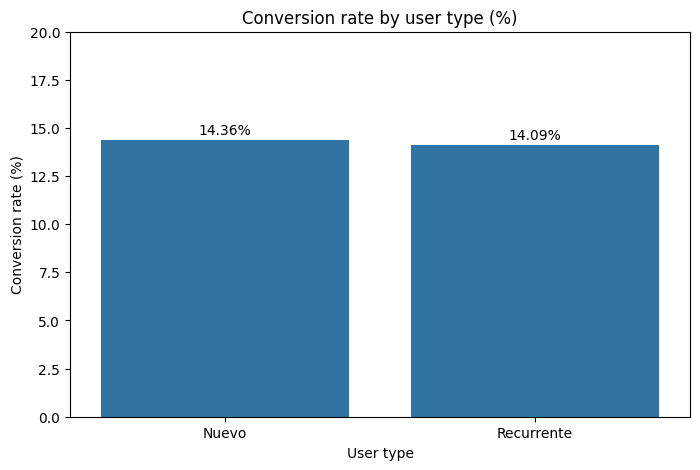

In [51]:
user_type_rates_pct = (user_type_rates[1] * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=user_type_rates_pct.index, y=user_type_rates_pct.values)
plt.title('Conversion rate by user type (%)')
plt.xlabel('User type')
plt.ylabel('Conversion rate (%)')
plt.ylim(0, 20)

for i, v in enumerate(user_type_rates_pct.values):
    plt.text(i, v + 0.3, f'{v}%', ha='center')

plt.show()


Comparing rates instead of volumes makes the gap from the previous chart disappear: new users convert at 14.36% and returning users at 14.09%, a 0.27 percentage point difference. The visual gap in the earlier chart came purely from the size of the new-user group, not from higher efficiency.

I fixed the axis from 0 to 20% so the difference is shown at its real magnitude, consistent with the non-significant chi-square result.

## 7. Recommendation

I turn the four results into a concrete decision: what to ship, what to leave alone, and what remains to be measured.

---

### What I found

#### **Page A against page B**

**Spend per converted user:**
- Users who bought on page B spent 68.75 on average against 61.09 on page A:
7.66 more per buyer.
- That is a 12.5% increase in average ticket, and it is not explained by random
variation.
- **Interpretation:** page B does not just attract purchases, it attracts
higher-value ones. Every customer converting on B leaves more money than one converting on A, which amplifies the return on any conversion improvement.

<br>

**Conversion rate:**
- Page B converted 15.96% of its visitors against 12.57% for page A: 3.38
percentage points more.
- In relative terms B converts 26.9% better than A, a gap too consistent to
attribute to chance.
- **Interpretation:** combining both results, each user landing on page B
generates 10.97 in revenue on average against 7.68 on page A — 43% more. B's advantage does not come from a single factor: it converts more visitors and each one spends more.

---

#### **Acquisition channel**
- Email (14.99%) and Ads (14.74%) convert above Referral (13.88%) and Organic
(13.79%), but the spread between best and worst is just 1.20 percentage points. Organic has the lowest rate and the highest traffic volume, so it delivers the largest absolute number of conversions.
- **Interpretation:** channel does influence conversion, but far less than page
version does. The spread between channels is three times smaller than the gain from switching pages, so it does not justify an aggressive budget reallocation. Cutting Organic for its lower rate would be counterproductive: it is the channel producing the most total conversions.

---

#### **User type**
- New users convert at 14.36% and returning users at 14.09%, a 0.27 percentage
point gap indistinguishable from noise. The higher conversion count among new users reflects group size, not efficiency.
- **Interpretation:** the page performs equivalently for both profiles. No
segmented rollout and no differentiated versions are needed, which simplifies deployment and reduces maintenance cost.

---

### What I recommend

- **Ship page B to all traffic.** It beats A on both components of revenue — 26.9%
more conversions and a 12.5% higher ticket — which works out to roughly 43% more revenue per exposed user. The rollout can be uniform, since the effect is consistent across new and returning users.
- **Keep the current channel budget allocation.** Conversion differences between
channels are marginal (1.20 p.p.) and do not support reallocation. Any channel decision should rest on acquisition cost, which this experiment did not measure.
- **Validate before the final rollout.** The analysis does not account for the
cost of implementing page B nor for possible novelty effects. Conversion and spend should be monitored over the first weeks after the change, and a next phase should evaluate the interaction between page version and user type.